In [ ]:
print("hello world")

hello world


# 🧪 Image Segmentation with Thresholding and Active Contours

In this notebook, I explore fundamental image segmentation techniques using **scikit-image** and **matplotlib**. The primary goal is to understand and implement segmentation using:

- **Manual thresholding** on grayscale images
- **Hue-based segmentation** in the HSV color space
- **Active Contour (Snake) model** for boundary-based segmentation

I work with built-in sample images like the popular `coffee` image to demonstrate how different **segmentation strategies** affect the output. Each approach is visualized step-by-step to give intuitive insights into how threshold values or contour evolution influence the results.

This exercise is part of my hands-on learning in **digital image processing**, aimed at building a solid understanding of segmentation at the pixel and region levels before moving into more advanced, deep learning-based methods.

I have **added comments** for each line as explanation.

Let’s dive in and explore how **classical segmentation techniques** operate under the hood! 🧠🔍


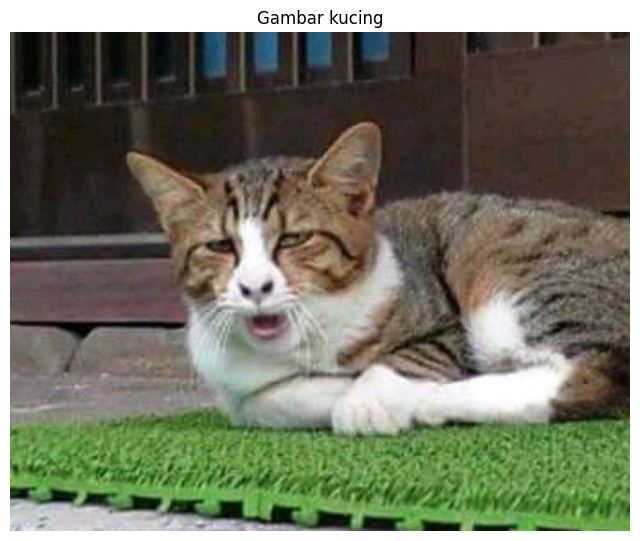

In [12]:
from skimage import io
import matplotlib.pyplot as plt

# Membaca gambar mawar dari file
mawar = io.imread('11.jpg')  # pastikan path-nya sesuai

# Menampilkan gambar
plt.figure(figsize=(8, 8))
plt.imshow(mawar)
plt.title("Gambar kucing")
plt.axis('off')
plt.show()


(746, 750, 3)


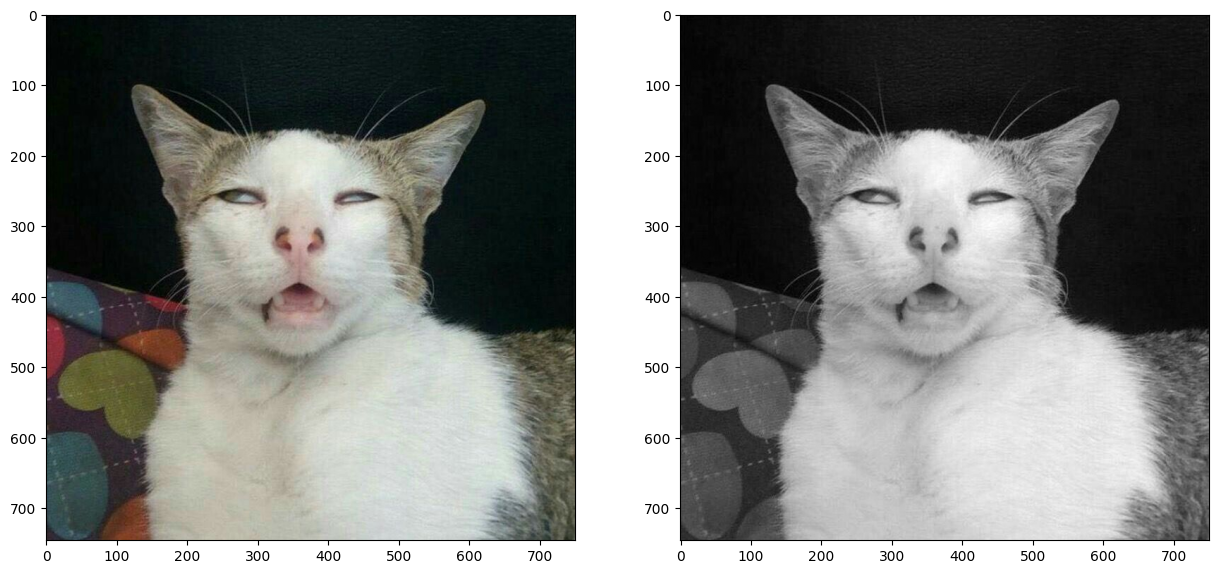

In [2]:
from skimage import io  # importing sample images from skimage
from skimage.color import rgb2gray  # its a function to convert RGB images to grayscale # segmentasi itu biasanya / awalnya dilakukan pada satu layer
import matplotlib.pyplot as plt  # matplotlib is for image visualization


# mengatur visualisasi
plt.figure(figsize=(15, 15))  # setting the plot size to 15x15

# ganti dengan gambar kalian masing-masing
mangga = io.imread('22.jpg')   # loading a sample image (coffee image) from scikit-image package


plt.subplot(1, 2, 1)  # Selecting the first subplot (1 row, 2 columns, first plot)
plt.imshow(mangga )  # displaying the original sample image

gray_mangga = rgb2gray(mangga )  # converting the RGB image to grayscale (monochrome)
plt.subplot(1, 2, 2)  # selecting the second subplot (1 row, 2 columns, second plot)
plt.imshow(gray_mangga , cmap="gray")  # displaying the grayscale image with the "gray" colormap

print(mangga .shape)


# Segmentation by Thresholding – Manual Input

There are detailed comments for explanation

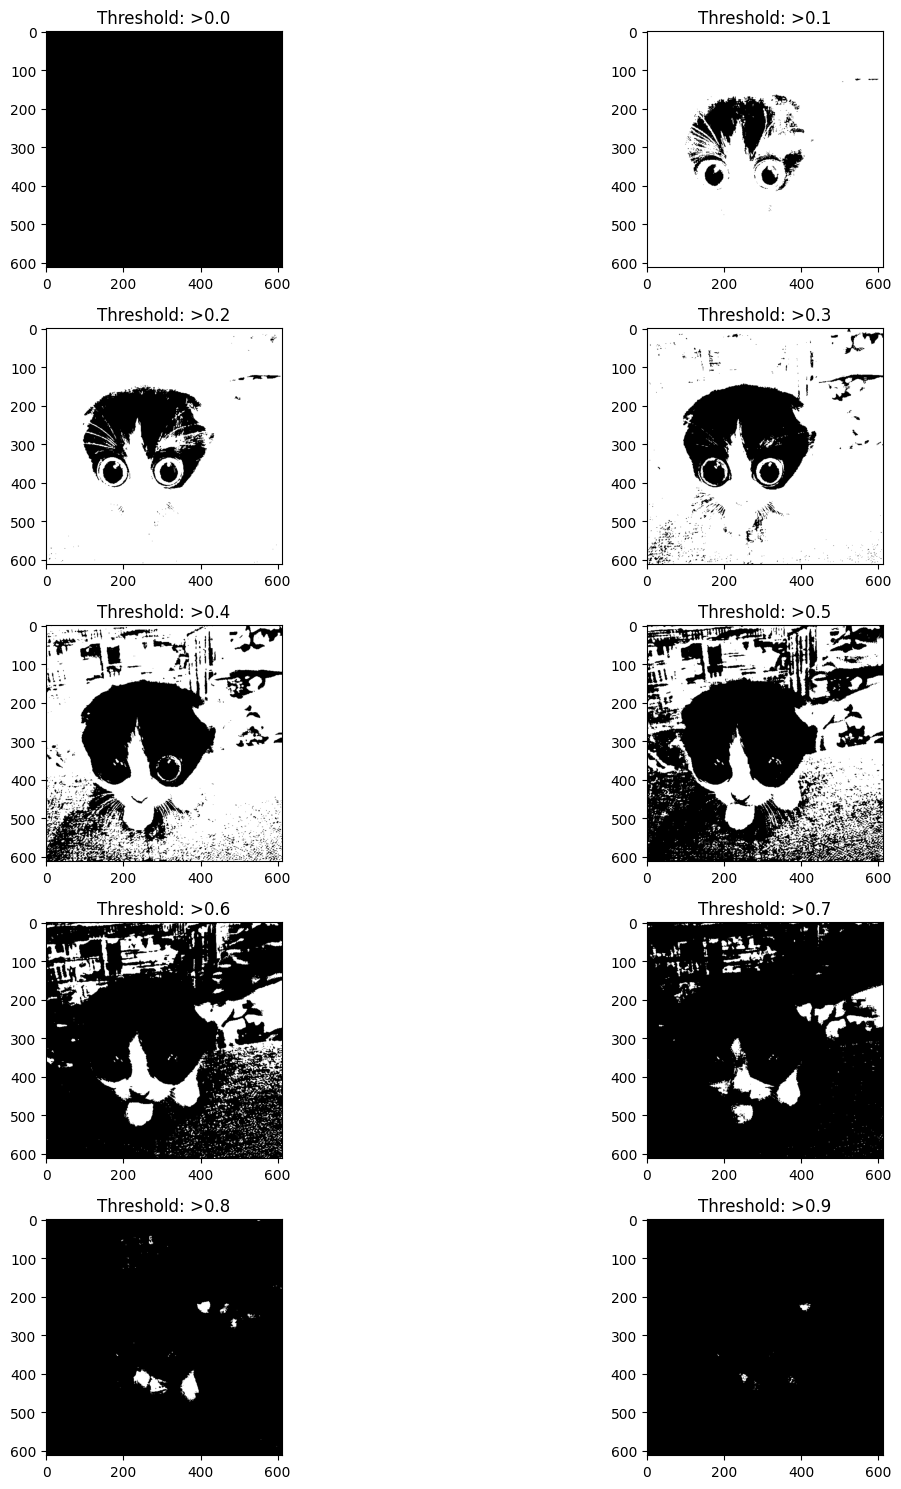

In [3]:
from skimage import io  # importing sample images from skimage
from skimage import filters  # importing filters module from skimage
from skimage.color import rgb2gray  # importing function to convert rgb images to grayscale
import matplotlib.pyplot as plt  # importing matplotlib for image visualization

mangga = io.imread('33.jpg')  # loading a sample image (coffee image) from scikit-image package
gray_mangga = rgb2gray(mangga)  # converting the rgb image to grayscale (monochrome)

plt.figure(figsize=(15, 15))  # setting the plot size to 15x15

for i in range(10):
    binarized_gray = (gray_mangga > i*0.1)*1  # iterating different thresholds

    #Compares each pixel in gray_coffee to a threshold value (i*0.1).
        # If the pixel intensity is greater than the threshold, it is set to True (1, white). 1*1 = 1 so white
        # Otherwise, it is set to False (0, black) like... 0*1 = 0
        # * 1: Converts the boolean array into an integer array (1 for white, 0 for black).
# example
# If i = 3, then the threshold is 3 * 0.1 = 0.3.
# All pixels with intensity greater than 0.3 become white (1), and the rest become black (0).

    plt.subplot(5, 2, i+1)  # creating a subplot with 5 rows and 2 columns

    plt.title("Threshold: >"+str(round(i*0.1,1)))  # rounding off the threshold value to 1 decimal point...... wont actually go to infinty without it, it would cause comparison errors while plotting and all

    plt.imshow(binarized_gray, cmap='gray')  # displaying the binarized image of various thresholds

plt.tight_layout()  # adjusting layout to prevent overlap


[[0.26832627 0.28009098 0.28710078 ... 0.13238706 0.14807333 0.16375961]
 [0.26440471 0.28009098 0.29102235 ... 0.13630863 0.15591647 0.17552431]
 [0.26048314 0.28009098 0.29102235 ... 0.14106353 0.16851451 0.18812235]
 ...
 [0.80142078 0.77789137 0.83279333 ... 0.57048    0.57048    0.57048   ]
 [0.78573451 0.7622051  0.81710706 ... 0.57832314 0.57832314 0.57832314]
 [0.7622051  0.73867569 0.79357765 ... 0.58224471 0.58224471 0.58224471]]


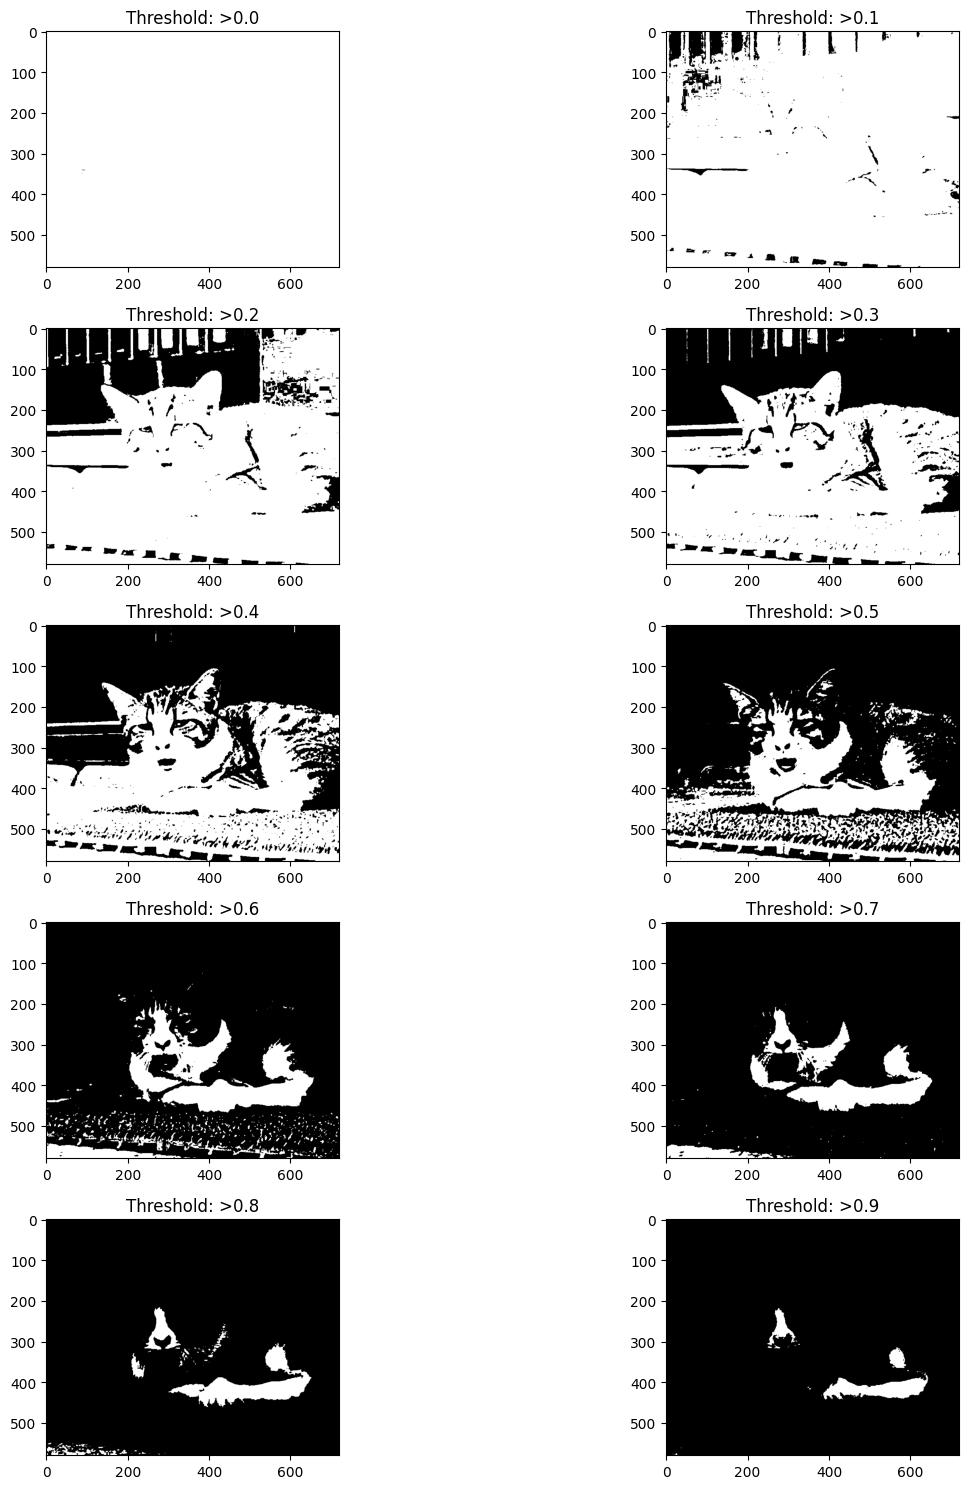

In [4]:
from skimage import io, exposure
from skimage.color import rgb2gray
from skimage.util import img_as_float
import matplotlib.pyplot as plt

# Membaca gambar
ti_girls = io.imread('11.jpg')

# Konversi ke grayscale
gray_ti_girls = rgb2gray(ti_girls)

# 🔑 Normalisasi ke rentang [0,1]
gray_ti_girls = exposure.rescale_intensity(gray_ti_girls, in_range='image', out_range=(0,1))
# atau cukup:
# gray_mangga = img_as_float(gray_mangga)

print(gray_ti_girls)
plt.figure(figsize=(15, 15))

# Thresholding dengan berbagai nilai
for i in range(10):
    binarized_gray = (gray_ti_girls > i*0.1) * 1

    plt.subplot(5, 2, i+1)
    plt.title("Threshold: >" + str(round(i*0.1, 1)))
    plt.imshow(binarized_gray, cmap='gray')

plt.tight_layout()
plt.show()


# Active Contour Segmentation

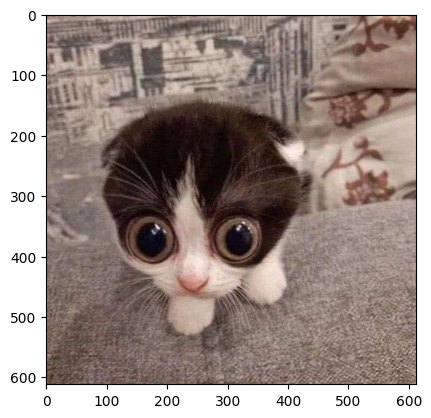

In [5]:
import numpy as np  # importing numpy for numerical operations
import matplotlib.pyplot as plt  # importing matplotlib for visualization
from skimage.color import rgb2gray  # importing function to convert rgb images to grayscale
from skimage import io # importing sample images from skimage


from skimage.filters import gaussian  # importing gaussian filter to reduce noise
from skimage.segmentation import active_contour  # importing active contour function for segmentation



ti_girls = io.imread('33.jpg') # loading a sample image (astronaut image) from scikit-image package
gray_ti_girls = rgb2gray(ti_girls)  # converting the rgb image to grayscale

plt.imshow(ti_girls)  #just checking the image
gray_ti_girls_noiseless = gaussian(gray_ti_girls, 1)  # applying gaussian filter to remove noise, as gaussian filter blurs the image, smoothing out noise while keeping the important structures.
# here sigma = 1,  higher sigma makes the image blurrier.





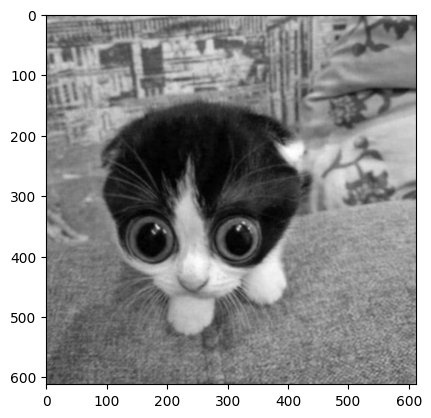

In [6]:
plt.imshow(gray_ti_girls_noiseless,'gray')

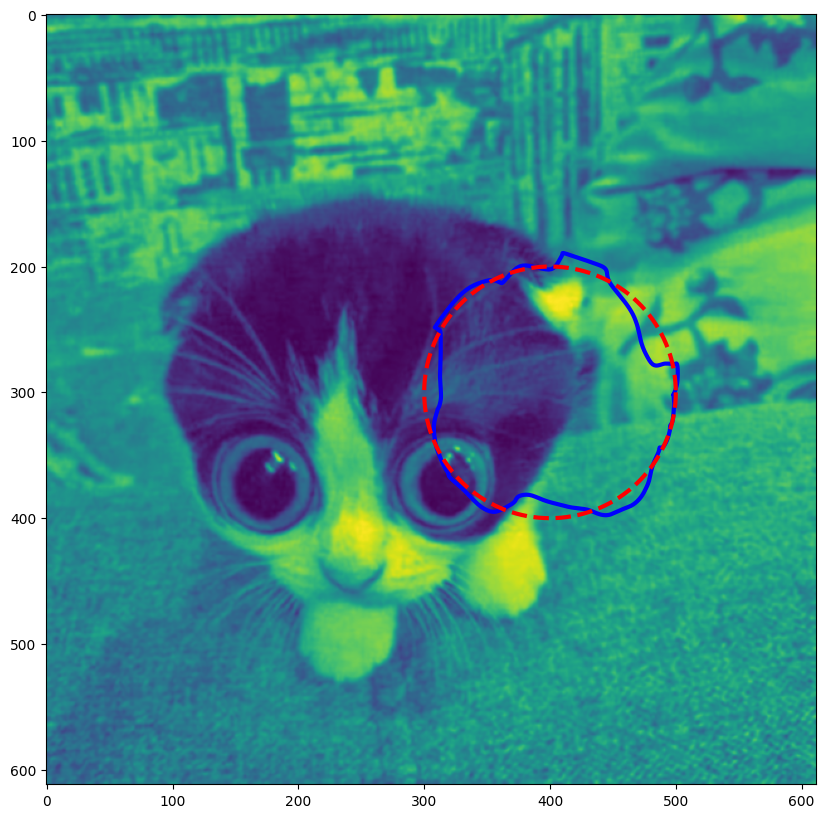

In [7]:
# import numpy as np
x1 = 400 + 100 * np.cos(np.linspace(0, 2 * np.pi, 700))  # localizing the circle's center at (220, 110) for x-coordinates
x2 = 300 + 100 * np.sin(np.linspace(0, 2 * np.pi, 700))  # localizing the circle's center at (220, 110) for y-coordinates

# A circle can be defined parametrically as:
#  𝑥 = 𝑥(center) + 𝑅cos(𝜃)
#  y = y(center)+Rsin(θ)
# np.linspace(0, 2 * np.pi, 500): Creates 500 points from 0 to 2π (full circle).
# np.cos() and np.sin(): Compute the X and Y coordinates of points on the circle.
# The circle is centered at (220, 110), and its radius is 100.

snake = np.array([x1, x2]).T  # generating a circle based on x1, x2 //

ti_girls_snake = active_contour(gray_ti_girls_noiseless, snake)  # computing the active contour for the given image

# the Active Contour (Snake) Algorithm
# It is an energy-minimizing curve that evolves over an image to find object boundaries.
# The curve attracts itself towards edges based on the gradient of the image.
# Useful for object segmentation (e.g., detecting a person's face).
#code line: -
# active_contour(gray_astronaut_noiseless, snake):
# Takes the smoothed grayscale image.
# Uses the initial circular contour (snake).
# Refines the contour to fit the boundary of the astronaut's face.


fig = plt.figure(figsize=(10, 10))  # setting the figure size to 10x10

ax = fig.add_subplot(111)  # adding a subplot to display the markers

ax.imshow(gray_ti_girls_noiseless)  # plotting the sample image



ax.plot(ti_girls_snake[:, 0], ti_girls_snake[:, 1], '-b', lw=3)  #
# astronaut_snake[:, 0]: X-coordinates of the final contour.
# astronaut_snake[:, 1]: Y-coordinates of the final contour.
# '-b': Blue solid line ('-').
# lw=5: Line width of 5 pixels

ax.plot(snake[:, 0], snake[:, 1], '--r', lw=3)  # plotting the circle around the face

plt.show()  # displaying the output


# Hue-based segmentation in the HSV color space

<class 'numpy.ndarray'> (580, 720, 3) uint8


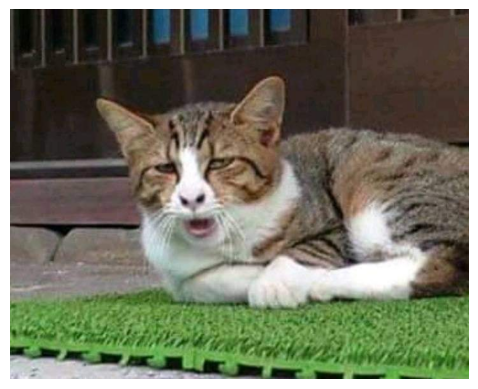

(<matplotlib.image.AxesImage at 0x2d49c790190>,
 (np.float64(-0.5), np.float64(719.5), np.float64(579.5), np.float64(-0.5)),
 None)

In [8]:
import imageio.v2 as imageio
im = imageio.imread('11.jpg')
print(type(im), im.shape, im.dtype)
plt.imshow(im), plt.axis('off'), plt.show()

Text(0.5, 1.0, 'Value')

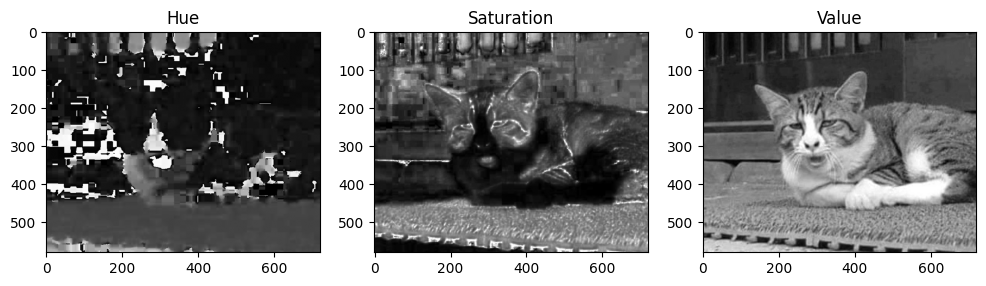

In [9]:
from skimage.color import rgb2hsv  # importing function to convert rgb image to hsv

im_hsv = rgb2hsv(im)  # converting the rgb image to hsv

fig, ax = plt.subplots(1, 3, figsize=(12, 4))  # creating a figure with 1 row and 3 columns, setting size to 12x4

ax[0].imshow(im_hsv[:, :, 0], cmap='gray')  # displaying the hue channel in grayscale
ax[0].set_title('Hue')  # setting title for the hue channel

ax[1].imshow(im_hsv[:, :, 1], cmap='gray')  # displaying the saturation channel in grayscale
ax[1].set_title('Saturation')  # setting title for the saturation channel

ax[2].imshow(im_hsv[:, :, 2], cmap='gray')  # displaying the value channel in grayscale
ax[2].set_title('Value')  # setting title for the value channel


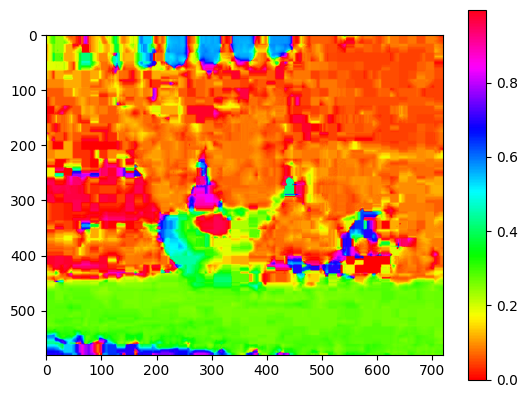

In [10]:
plt.imshow(im_hsv[:,:,0],cmap='hsv')
plt.colorbar()

## Let us now try to threshold the image using the Hue par of the HSV color channel to segment the image.

### Red

In [11]:
import matplotlib.pyplot as plt  # importing imread to load an image and imshow to display an image

lower_mask = (im_hsv[:, :, 0] > 0.70) | (im_hsv[:, :, 0] < 0.10) #------------------------------------------------------------------------- say the scale in the above image and combined 0-0.1 too for a better image
upper_mask = im_hsv[:, :, 0] < 1  # creating a boolean mask where the hue value is less than 1

mask = upper_mask * lower_mask  # performing element-wise multiplication to get the final hue range mask

plt.imshow(im_masked)  # displaying the binary mask to visualize the selected hue range

red = im[:, :, 0] * mask  # extracting the red channel and applying the mask to retain only selected pixels
green = im[:, :, 1] * mask  # extracting the green channel and applying the mask to retain only selected pixels
blue = im[:, :, 2] * mask  # extracting the blue channel and applying the mask to retain only selected pixels

im_masked = np.dstack((red, green, blue))  # stacking the masked red, green, and blue channels to reconstruct the image

imshow(im_masked)  # displaying the final masked image where only selected hues are preserved


NameError: name 'im_masked' is not defined

### Yellow

In [ ]:
lower_mask = im_hsv[:, :, 0] > 0.1  # creating a mask where the hue value is greater than 0.08
# selecting pixels that have a hue value above 0.08 ensures that we include certain shades of colors within this range

upper_mask = im_hsv[:, :, 0] < 0.2  # creating a mask where the hue value is less than 0.19
# limiting the hue value to below 0.19 helps in isolating a specific range of colors, preventing unwanted colors from being included

mask = upper_mask * lower_mask  # performing element-wise multiplication to retain only the pixels within the hue range
# combining both masks allows us to extract pixels where the hue is between 0.08 and 0.19, effectively filtering a specific color range

plt.imshow(mask)  # displaying the binary mask to visualize the filtered color region

red = im[:, :, 0] * mask  # extracting the red channel and applying the mask to retain only the selected color region
# ensures that only the relevant parts of the red channel are preserved

green = im[:, :, 1] * mask  # extracting the green channel and applying the mask to retain only the selected color region
# keeps only the green values of the filtered region, discarding the rest

blue = im[:, :, 2] * mask  # extracting the blue channel and applying the mask to retain only the selected color region
# preserves the blue values of the filtered region while setting other areas to zero

im_masked = np.dstack((red, green, blue))  # stacking the masked red, green, and blue channels to reconstruct the final image
# reconstructs the color image where only pixels within the defined hue range are retained

imshow(im_masked)  # displaying the final masked image with only the selected color range


### Blue

In [ ]:
lower_mask = im_hsv[:, :, 0] > 0.52  # tweaked this for better blue color
# selecting pixels with a hue above 0.52 helps in isolating colors within this range, typically shades of blue

upper_mask = im_hsv[:, :, 0] < 0.75  # tweaked this for better blue color

mask = upper_mask * lower_mask  # performing element-wise multiplication to retain only the pixels within the hue range
# combining both masks results in a final binary mask where only colors with a hue between 0.58 and 0.7 are retained

plt.imshow(mask, cmap = "gray")  # displaying the binary mask to visualize the selected color region
plt.show()
red = im[:, :, 0] * mask  # extracting the red channel and applying the mask to retain only the selected color region
# ensures that only the relevant red channel values remain in the final image

green = im[:, :, 1] * mask  # extracting the green channel and applying the mask to retain only the selected color region
# preserves the green values of the filtered area while setting the rest to zero

blue = im[:, :, 2] * mask  # extracting the blue channel and applying the mask to retain only the selected color region
# keeps only the blue values of the pixels that fall within the defined hue range

im_masked = np.dstack((red, green, blue))  # stacking the masked red, green, and blue channels to reconstruct the final image
# reconstructs a color image where only the pixels with hues between 0.58 and 0.7 are retained

plt.imshow(im_masked)  # displaying the final masked image with only the selected color range
plt.show()

# **Color Segmentation using HSV Thresholding**


## **📌 Steps Performed**
1. **Load the Image** 📷  
   - The image is read using `imread()` and converted to **HSV format**.

2. **Apply Thresholding** 🎨  
   - Define **HSV ranges** to segment:
     - **Red**: `Hue in [0.7 - 1.0] OR [0 - 0.1]`
     - **Blue**: `Hue in [0.52 - 0.75]`
     - **Yellow**: `Hue in [0.1 - 0.2]`

3. **Extract Segmented Colors** 🎭  
   - Create binary masks for each color and apply them to the original image.

4. **Display Results** 🖼️  
   - Show the **original image** alongside **segmented images** (Red, Blue, Yellow) using **Matplotlib**.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.io import imread, imshow

# Load the image
im = imread("11.jpg")

# Convert the image to HSV
im_hsv = rgb2hsv(im)

# Define HSV thresholds for Red, Blue, and Yellow

## the values are same that I took above :-------------------------------------


# Red Mask (Combining two ranges to capture both ends of the hue spectrum)
red_mask = ((im_hsv[:, :, 0] > 0.70) | (im_hsv[:, :, 0] < 0.10)) & (im_hsv[:, :, 0] < 1)

# Blue Mask (Tweaked values for better segmentation)
blue_mask = (im_hsv[:, :, 0] > 0.52) & (im_hsv[:, :, 0] < 0.75)

# Yellow Mask (Tweaked values for better segmentation)
yellow_mask = (im_hsv[:, :, 0] > 0.1) & (im_hsv[:, :, 0] < 0.2)

# Function to apply mask and extract a segmented color
def apply_mask(image, mask):
    red = image[:, :, 0] * mask
    green = image[:, :, 1] * mask
    blue = image[:, :, 2] * mask
    return np.dstack((red, green, blue))

# Apply masks to extract segmented images
red_segmented = apply_mask(im, red_mask)
blue_segmented = apply_mask(im, blue_mask)
yellow_segmented = apply_mask(im, yellow_mask)

# Plot Original and Segmented Images
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(im)
ax[0].set_title("Original Image")

ax[1].imshow(red_segmented)
ax[1].set_title("Red Segmented")

ax[2].imshow(blue_segmented)
ax[2].set_title("Blue Segmented")

ax[3].imshow(yellow_segmented)
ax[3].set_title("Yellow Segmented")

for a in ax:
    a.axis("off")

plt.show()


# **Hue-Based Image Segmentation**

## **Algorithm**

### **1. Initialize the Segmenter**
- Define the `HSVSegmenter` class for image segmentation.
- Load the image using `imread()`.
- Convert the image from **RGB to HSV** for hue-based segmentation.

### **2. Load and Validate Image**
- Implement `_load_image()` to read the image file.
- Handle errors if the image cannot be loaded properly.

### **3. Create Binary Masks for Segmentation**
- Implement `_create_mask(hue_range)` to generate binary masks based on hue values.
- Define hue thresholds for different colors:
  - **Red**: Hue in `[0.7 - 1.0] OR [0 - 0.1]`
  - **Blue**: Hue in `[0.52 - 0.75]`
  - **Yellow**: Hue in `[0.1 - 0.2]`
- Red requires a special condition as it spans two hue ranges.

### **4. Apply Mask to Extract Colors**
- Implement `_apply_mask(mask)` to retain only the pixels matching the mask.
- Create a blank image and copy the original pixels **where the mask is True**.

### **5. Segment the Colors**
- Define `segment_colors()` to process Red, Blue, and Yellow segmentation.
- Generate binary masks and extract segmented images for each color.

### **6. Display Results**
- Implement `_plot_results(segmented_images)` to visualize the original and segmented images.
- Display images side by side using **Matplotlib**.

### **7. Execute the Segmentation**
- Instantiate `HSVSegmenter` with the image path.
- Call `segment_colors()` to process and visualize segmentation results.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.io import imread

class HSVSegmenter:
    """Class for segmenting an image based on predefined hue thresholds."""

    def __init__(self, image_path: str):
        """
        Initialize the segmenter with an image path.

        Parameters:
            image_path (str): Path to the image file.
        """
        self.image = self._load_image(image_path)
        self.hsv_image = rgb2hsv(self.image)

    def _load_image(self, image_path: str):
        """Load the image and handle errors."""
        try:
            image = imread(image_path)
            if image is None:
                raise ValueError("Failed to load image.")
            return image
        except Exception as e:
            raise RuntimeError(f"Error loading image: {e}")

    def _create_mask(self, hue_range):
        """
        Create a binary mask based on hue thresholds.

        Parameters:
            hue_range (tuple): Min and max hue values (0 to 1).

        Returns:
            np.ndarray: Binary mask for the selected color range.
        """
        h = self.hsv_image[:, :, 0]

        # Handle Red separately (spanning two hue ranges)
        if hue_range == (0.7, 1.0):
            mask = (h >= 0.7) | (h <= 0.1)  # Red has two ranges (0-0.1 and 0.7-1)
        else:
            mask = (h >= hue_range[0]) & (h <= hue_range[1])

        return mask

    def _apply_mask(self, mask):
        """
        Apply a binary mask to extract the segmented color from the original image.

        Parameters:
            mask (np.ndarray): Binary mask for segmentation.

        Returns:
            np.ndarray: Segmented image with only the masked color visible.
        """
        segmented = np.zeros_like(self.image)
        segmented[mask] = self.image[mask]
        return segmented

    def segment_colors(self):
        """
        Segment Red, Blue, and Yellow colors based on hue values only.
        """
        # Define hue ranges for each color
        color_ranges = {
            "Red": (0.7, 1.0),
            "Blue": (0.52, 0.75),
            "Yellow": (0.1, 0.2)
        }

        # Generate segmented images for each color
        segmented_images = {color: self._apply_mask(self._create_mask(hue_range))
                            for color, hue_range in color_ranges.items()}

        # Display results
        self._plot_results(segmented_images)

    def _plot_results(self, segmented_images):
        """
        Plot the original and segmented images.

        Parameters:
            segmented_images (dict): Dictionary mapping color names to segmented images.
        """
        fig, axes = plt.subplots(1, len(segmented_images) + 1, figsize=(20, 5))

        axes[0].imshow(self.image)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        for ax, (color, img) in zip(axes[1:], segmented_images.items()):
            ax.imshow(img)
            ax.set_title(f"{color} Segmented")
            ax.axis("off")

        plt.tight_layout()
        plt.show()

# Run the segmentation
if __name__ == "__main__":
    image_path = "22.jpg"
    segmenter = HSVSegmenter(image_path)
    segmenter.segment_colors()
